In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from option_functions import BlackScholes, imp_vol_call, imp_vol_put
import visualization

# Cicle

## Data

In [2]:
data = pd.read_excel('AAPL_Options.xlsx')
data['Date'] = pd.to_datetime(data['Date'])
data['Maturity'] = pd.to_datetime(data['Maturity'])

calls = data[data['Type'] == 'Call']
puts = data[data['Type'] == 'Put']

data.head()

,Contract Name,Last Trade Date (EDT),Strike,Last Price,Bid,Ask,Change,% Change,Volume,Open Interest,Implied Volatility,Type,S0,Date,Maturity
0,AAPL251121C00100000,8/22/2025 11:56 AM,100.0,128.57,128.65,132.30,0.0,0.0,1,8,0.9421,Call,229.72,2025-09-02,2025-11-21
1,AAPL251121C00105000,2025-11-08 11:05:00,105.0,122.55,123.70,127.35,0.0,0.0,2,0,0.9021,Call,229.72,2025-09-02,2025-11-21
2,AAPL251121C00110000,7/31/2025 10:57 AM,110.0,100.22,121.20,124.90,0.0,0.0,10,1,1.1539,Call,229.72,2025-09-02,2025-11-21
3,AAPL251121C00115000,8/19/2025 10:12 AM,115.0,119.07,113.80,117.45,0.0,0.0,3,10,0.8250,Call,229.72,2025-09-02,2025-11-21
4,AAPL251121C00120000,2025-05-08 12:53:00,120.0,85.11,108.90,112.50,0.0,0.0,2,3,0.7918,Call,229.72,2025-09-02,2025-11-21


## Calls

In [3]:
Strikes = calls.Strike.unique()
Strikes


array([100. , 105. , 110. , 115. , 120. , 125. , 130. , 135. , 140. ,
       145. , 150. , 155. , 160. , 165. , 170. , 175. , 180. , 185. ,
       190. , 195. , 200. , 205. , 210. , 215. , 220. , 225. , 230. ,
       235. , 240. , 245. , 250. , 255. , 260. , 265. , 270. , 275. ,
       280. , 285. , 290. , 295. , 300. , 305. , 310. , 315. , 320. ,
       325. , 330. , 335. , 340. , 345. , 350. , 212.5, 217.5, 222.5,
       227.5, 232.5, 237.5, 242.5, 247.5, 252.5, 257.5, 262.5, 267.5,
       272.5, 277.5, 282.5, 287.5, 292.5])

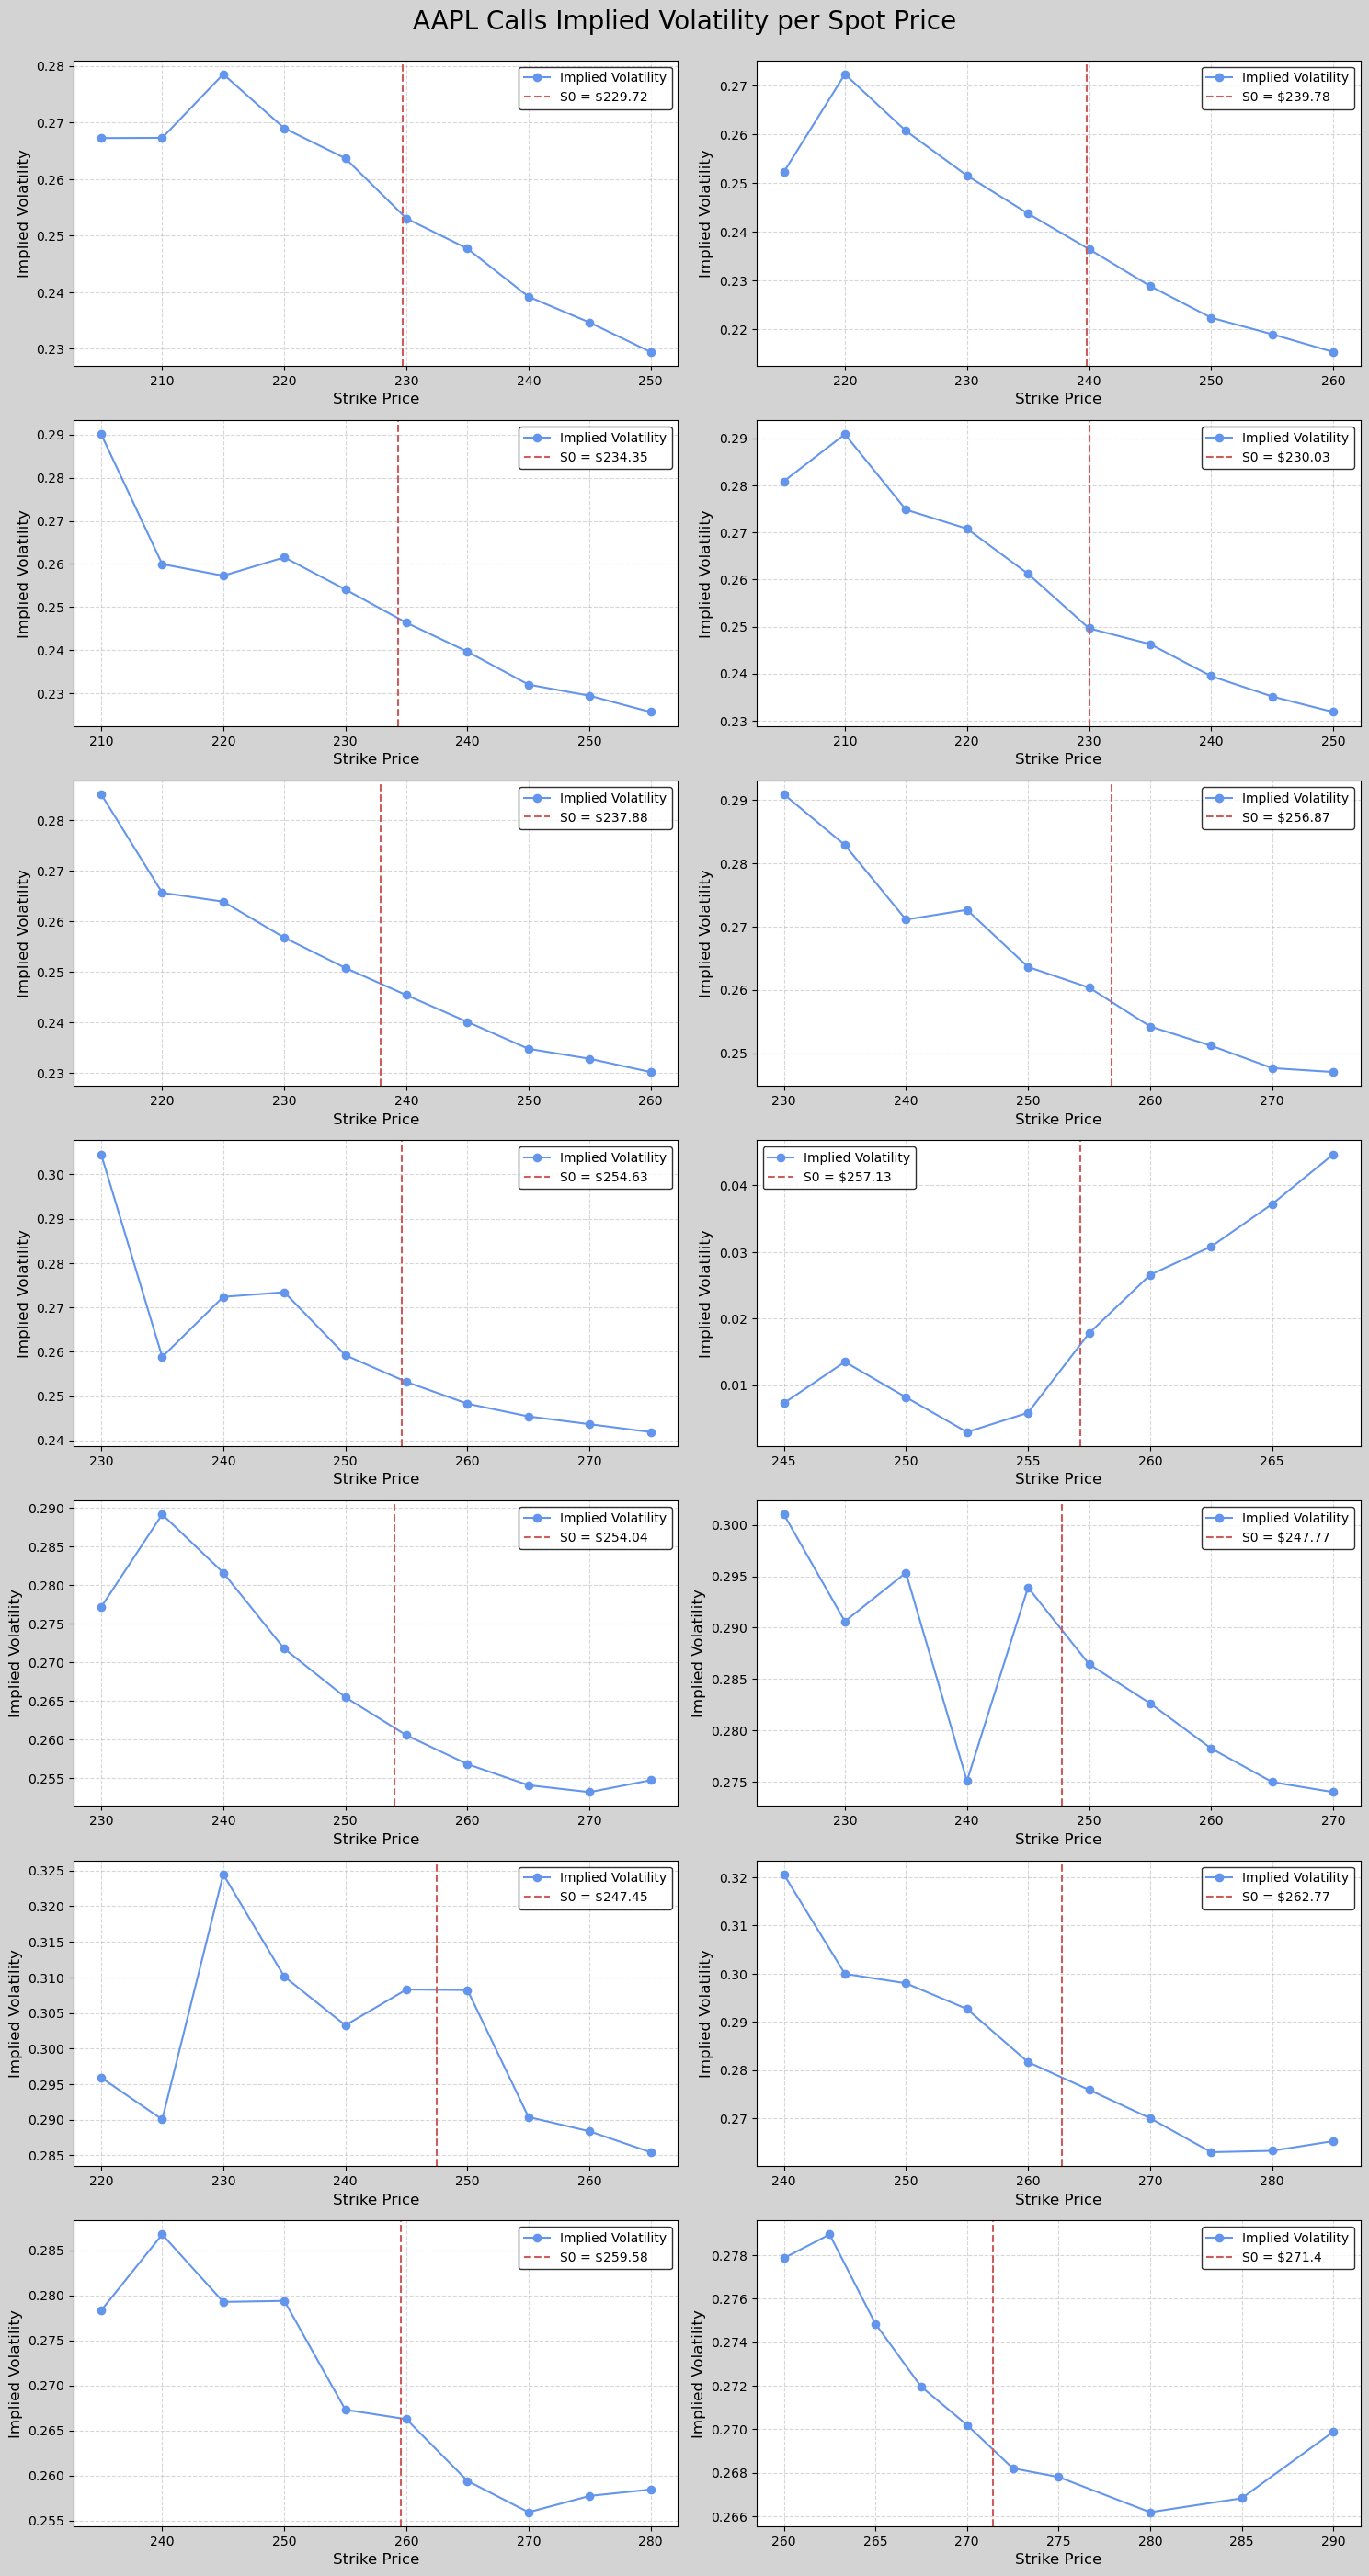

In [4]:
# Calls by Spot Price
Spots = calls.S0.unique()

call_by_S0 = []
for S0 in Spots:
    # Filter by Spot Price
    call_df = calls[calls.S0 == S0]

    # Find index label of closest value
    idx_closest = (call_df['Strike'] - S0).abs().idxmin()
    # Convert to integer position
    pos = call_df.index.get_loc(idx_closest)
    # Select rows before and after
    window = 5
    call_df = call_df.iloc[max(pos - window, 0) : pos + window]

    call_df = call_df.copy()

    # Calculate T
    call_df['T'] = (call_df['Maturity'] - call_df['Date']) / np.timedelta64(365, 'D')

    # Calculate Implied Volatility
    # Values
    St = call_df['S0'].values                # Spot price
    K = call_df['Strike'].values             # Strike price
    sigma = np.full(len(call_df), 0.3)       # Volatility
    r = np.full(len(call_df), 0.0382)        # Risk-free rate
    T = call_df['T'].values                  # Time to maturity
    t = np.full(len(call_df), 0)             # Current time
    CallMkt = call_df['Last Price'].values   # Market price of the call option

    vol = []
    for i in range(len(call_df)):
        vol.append(imp_vol_call(St[i], K[i], T[i], t[i], r[i], sigma[i], CallMkt[i]))

    # Add Implied Volatility to DataFrame
    call_df['ImpVol'] = vol

    # Store df
    call_by_S0.append(call_df)

# Visualization
n = len(call_by_S0)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, (df, S0) in enumerate(zip(call_by_S0, Spots)):
    ax = axes[i]
    
    # Plot Implied Volatility curve
    ax.plot(df['Strike'], df['ImpVol'], marker='o', color='cornflowerblue', label='Implied Volatility')
    
    # Add vertical line for the Spot Price
    ax.axvline(x=S0, color='indianred', linestyle='--', label=f'S0 = ${S0}')
    
    # Axis labels
    ax.set_xlabel('Strike Price')
    ax.set_ylabel('Implied Volatility')
    
    # Legend
    ax.legend()

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('AAPL Calls Implied Volatility per Spot Price', fontsize=20, y=0.999)

plt.tight_layout()
plt.show()

## Puts

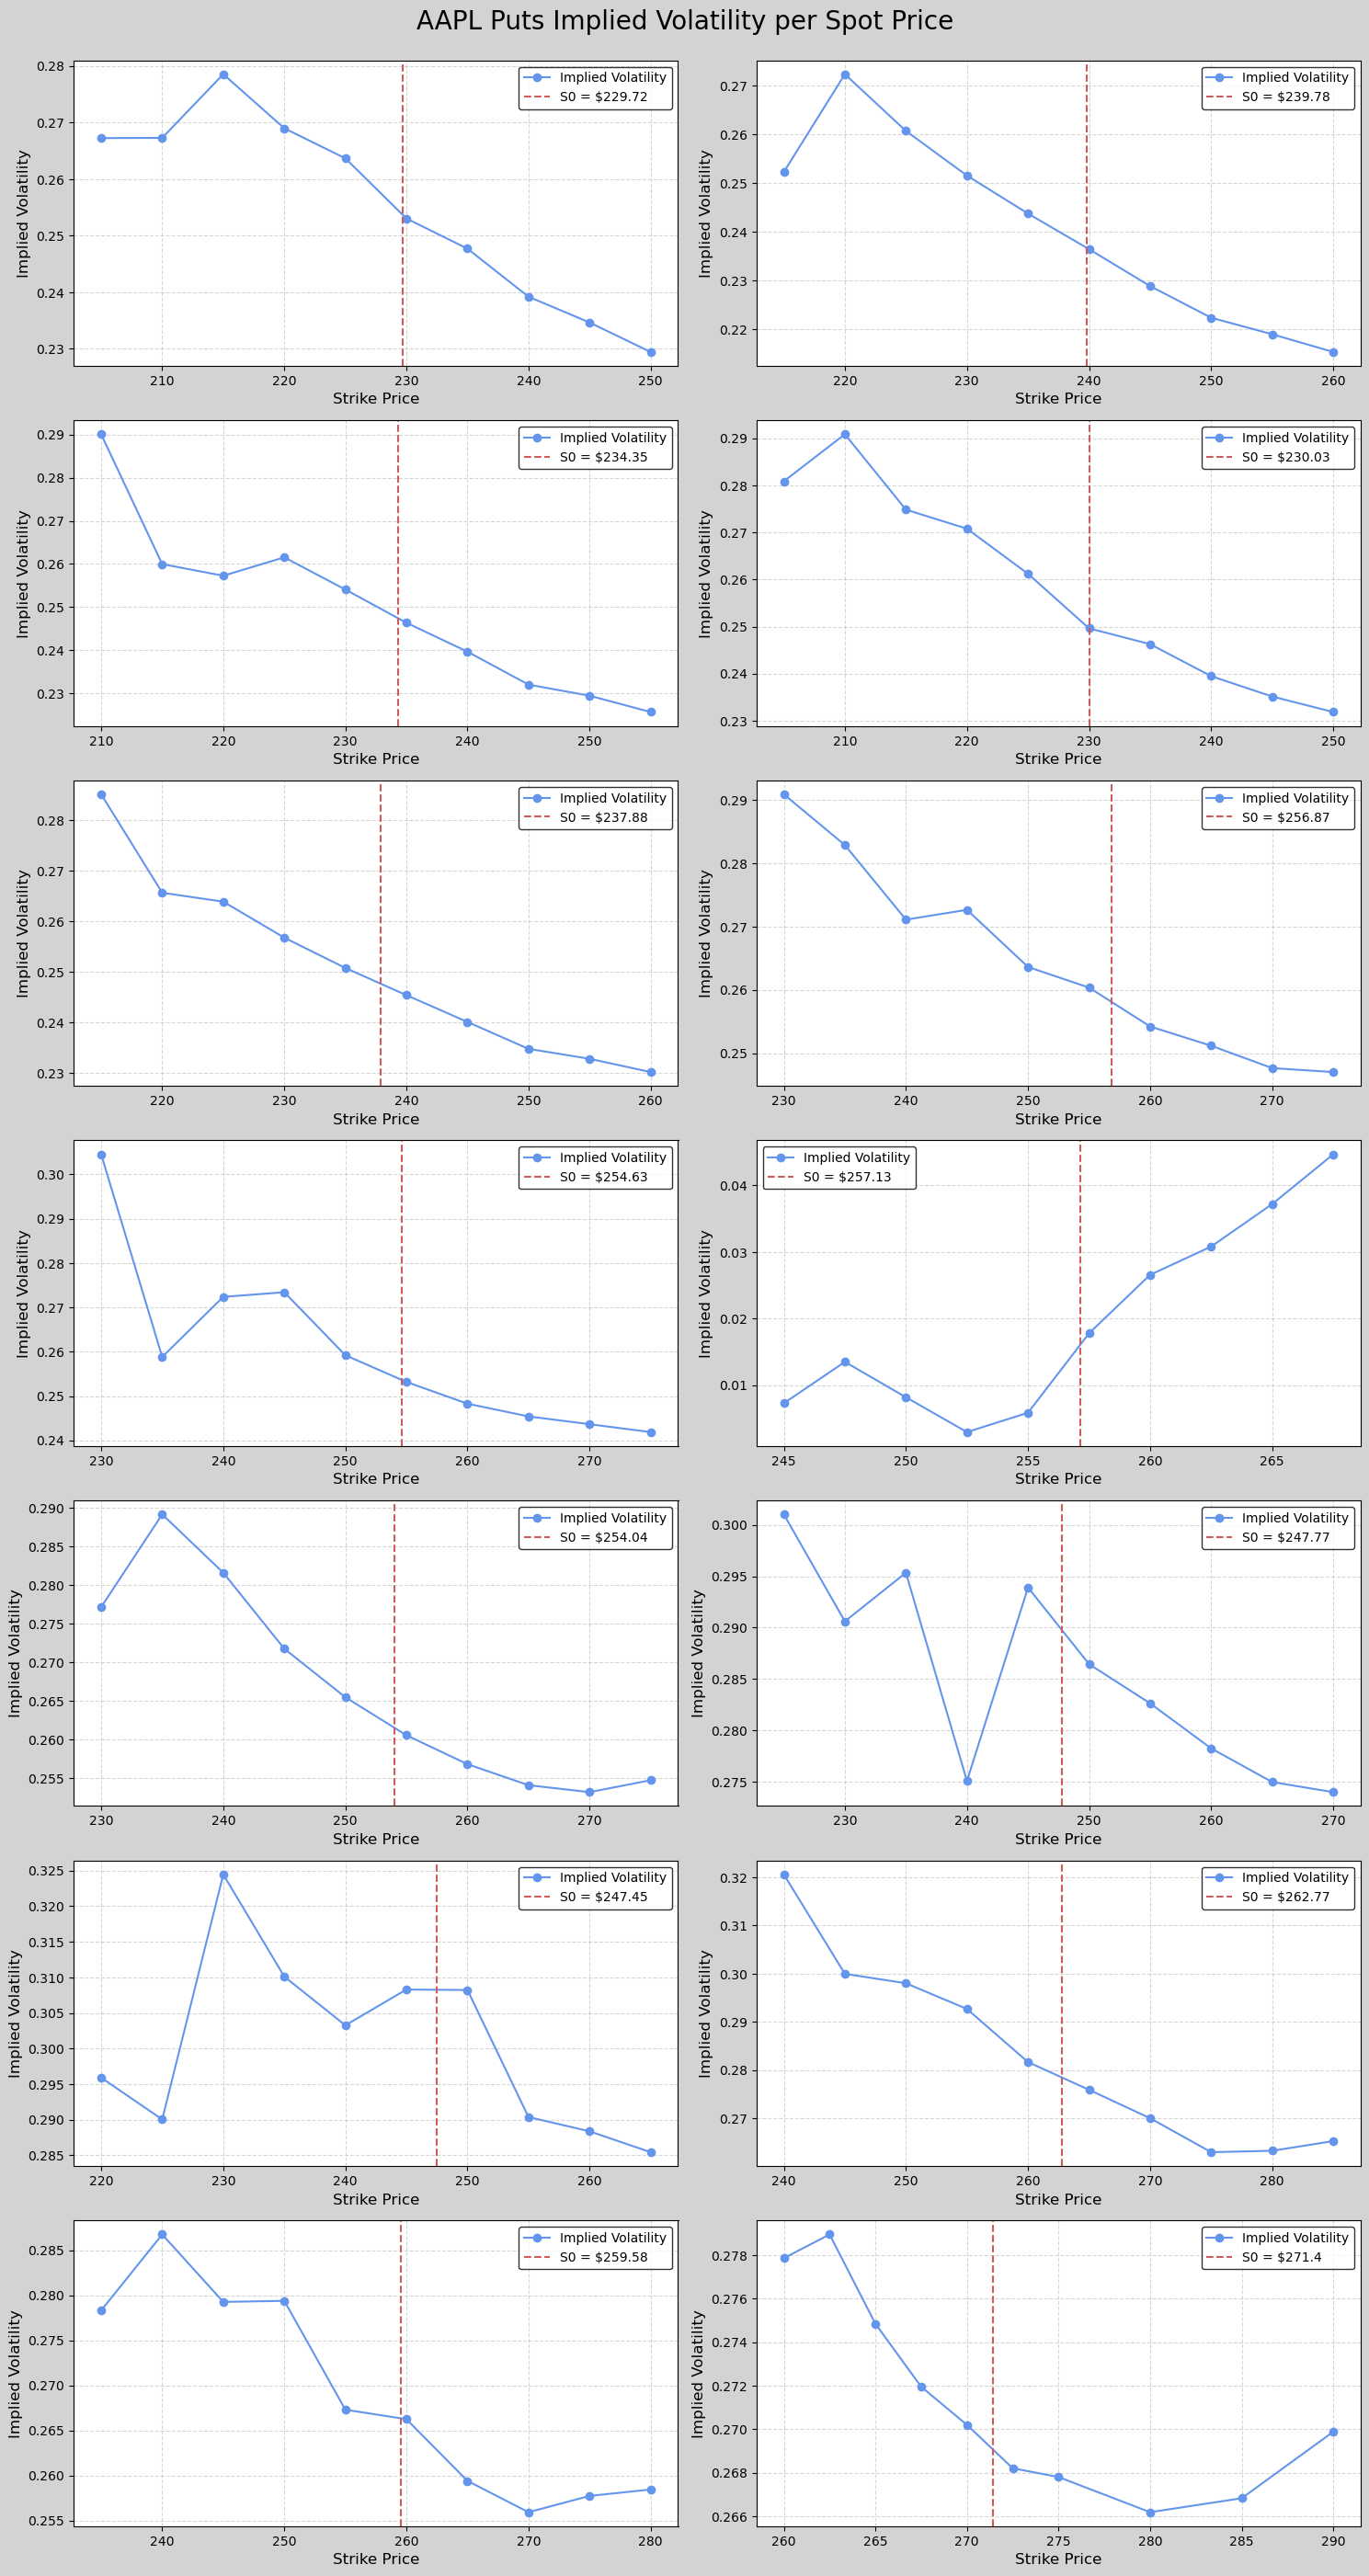

In [5]:
# Calls by Spot Price
Spots = puts.S0.unique()

put_by_S0 = []
for S0 in Spots:
    # Filter by Spot Price
    put_df = puts[puts.S0 == S0]

    # Find index label of closest value
    idx_closest = (put_df['Strike'] - S0).abs().idxmin()
    # Convert to integer position
    pos = put_df.index.get_loc(idx_closest)
    # Select rows before and after
    window = 5
    put_df = put_df.iloc[max(pos - window, 0) : pos + window]

    put_df = put_df.copy()

    # Calculate T
    put_df['T'] = (put_df['Maturity'] - put_df['Date']) / np.timedelta64(365, 'D')

    # Calculate Implied Volatility
    # Values
    St = put_df['S0'].values                # Spot price
    K = put_df['Strike'].values             # Strike price
    sigma = np.full(len(put_df), 0.3)       # Volatility
    r = np.full(len(put_df), 0.0382)        # Risk-free rate
    T = put_df['T'].values                  # Time to maturity
    t = np.full(len(put_df), 0)             # Current time
    PutMkt = put_df['Last Price'].values    # Market price of the put option

    vol = []
    for i in range(len(put_df)):
        vol.append(imp_vol_put(St[i], K[i], T[i], t[i], r[i], sigma[i], PutMkt[i]))

    # Add Implied Volatility to DataFrame
    put_df['ImpVol'] = vol

    # Store df
    put_by_S0.append(put_df)

# Visualization
n = len(put_by_S0)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, (df, S0) in enumerate(zip(call_by_S0, Spots)):
    ax = axes[i]
    
    # Plot Implied Volatility curve
    ax.plot(df['Strike'], df['ImpVol'], marker='o', color='cornflowerblue', label='Implied Volatility')
    
    # Add vertical line for the Spot Price
    ax.axvline(x=S0, color='indianred', linestyle='--', label=f'S0 = ${S0}')
    
    # Axis labels
    ax.set_xlabel('Strike Price')
    ax.set_ylabel('Implied Volatility')
    
    # Legend
    ax.legend()

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('AAPL Puts Implied Volatility per Spot Price', fontsize=20, y=0.999)

plt.tight_layout()
plt.show()